# Diffusion models

*Nov 3, 2024*

*Updated: Sep 17, 2025*

**[Javad Komijani (ETH Zurich)](mailto:jkomijani@gmail.com)**

# Introduction

## Diffusion process

The diffusion process is described by a stochastic differential equation (SDE):
$$
  \frac{d}{dt} x_t = f(x_t) + \sqrt{2} \sigma \eta_t .
$$
Here, $x_t$ is the state of the system at diffusion time $t$,
$f(x_t)$ represents a deterministic drift term,
and $\eta_t$ is a stochastic term, often modeled as a standard white normal noise.

By setting the drift term to zero, we can define a diffusion model in the
framework of machine learning, and train it by applying certain simple
algorithms as discussed below.
However, this choice increases the time required for the diffusion process to
lose information about the initial distribution.
A straightforward modification is to choose a non-vanishing drift term as
$f(x_t) = - \gamma x_t$, which transforms the forward process into
$$
  \frac{d}{dt}\left(e^{\gamma t} x_t\right) = e^{\gamma t} \sqrt{2} \sigma \eta_t.
$$
This approach allows for the use of the same simple algorithms as those employed
in the case of vanishing drift, while also speeding up the loss of information
from the initial distribution.
The stochastic differential equation (SDE) can be solved in a closed form as
$$
  x_t = e^{-\gamma t} x_0 + \sigma \sqrt{\frac{1 - e^{-2\gamma t}}{\gamma}} \epsilon_t,
$$
where $\epsilon_t$ represents a normal variable with zero mean and unit variance.
We set $\sigma = \sqrt{\gamma}$ so that variance of $x_t$ approaches 1 at large
values of $t$, i.e., for $t \gg 1 / \gamma$.

### Reverse of diffusion process

The diffusion process can be reversed; however, this reverse process is not unique.
This reverse operation is commonly referred to as denoising process.
Indeed there is a one-parameter family of denoising process:
$$
  \frac{d}{dt} x_t = f(x_t) - (\sigma^2 + \tilde \sigma^2)
  \partial_{x_t} \ln p_t(x_t) + \tilde\sigma \eta_t
$$
for any real value of $\tilde\sigma$.
A denoising process aims to recover alternative samples of the original data
from the diffused version by removing the noise that is introduced during
the diffusion process. A crucial aspect of the denoising process is
understanding the so-called score function, i.e., the gradient of
$\ln p_t(x_t)$.


Interestingly, when $\tilde\sigma = 0$, the denoising process simplifies to
a completely deterministic flow, which can be interpreted as a continuous
normalizing flow.

## Loss function

### Explicit and implicit score matching
Score matching is a technique used to train models to approximate the data distribution
$p(x)$ by minimizing the difference between the true score $\partial_x \ln p(x)$
and the model score function $s(x; \theta)$, where $\theta$ is used to denote
the model parameters.
To simplify the score matching problem, it is often more practical to work with
the conditional distribution $p(x|x_0)$ instead of directly using the marginal
distribution $p(x)$.

To this end, [Ref.](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=6795935)
shows that for a function $s(x; \theta)$ such that the following integrals are
finite, we have:
$$
    \int dx\, p(x)\,
    \left\lVert s(x; \theta) - \partial_x \log p(x)\right\rVert^2 
    =
    \int\int dx dx_0 \, p(x, x_0)\,
    \left\lVert s(x; \theta) - \partial_x \log p(x|x_0)\right\rVert^2
    + \text{constant}\, .
$$
To derive the above relation, one can use the following identity
$$
    \int dx\, p(x) \Big\langle s(x; \theta), \partial_x \log p(x)\Big\rangle
    =
    \int\int dx dx_0\, p(x, x_0) \Big\langle s(x; \theta), \partial_x \log p(x|x_0)\Big\rangle
$$
which itself can be derived from
$$
    \partial_x p(x)
    =
    \int d x_0\, p(x, x_0)\, \partial_x \log p(x|x_0)\,.
$$

Therefore, in score matching, the conditional probability distribution
$p(x|x_0)$ can be used instead of the marginal distribution $p(x)$.
A loss function with the conditional and marginal distributions are named
implicit and explicit score matching, respectively.
Note that the constant appearing the above relation, is not necessarily finite.
To make the loss function finite an appropriate weight function is needed,
as discussed below.

For further discussion, see equations (11-14) of [arXiv:2209.00796](https://arxiv.org/abs/2209.00796).


### Loss function as a weighted integral
For the diffusion process the loss function is typically defined as a weighted
integral over diffusion time:
$$
    \text{Loss} = \int_0^T dt\, \lambda(t)\,
    \mathbb{E} \left[\left\lVert s(t, X_t; \theta)
    - \partial_{X_t} \log p_t(X_t|X_0)\right\rVert^2\right] \,.
$$
The weight function is typically set to a particular form that in our
convention reads: $\lambda(t) = 1 - e^{-2\gamma t}$. With this particular
weight we obtain
$$
    \sqrt{\lambda(t)}\, \partial_{x_t} \log p_t(x_t|x_0) = - \epsilon_t\,.
$$
Moreover, it suprresses the contribution of the constant difference between
the explicit and implicit score matching as $t$ approaches zero,
i.e.,
$$
 \lim_{t\to 0} \lambda(t)\,
    \mathbb{E} \left[\left\lVert \partial_{X_t} \log p_t(X_t)\right\rVert^2
    - \left\lVert \partial_{X_t} \log p_t(X_t|X_0)\right\rVert^2\right] 
$$
is finite as $t \to 0$.

So far, we have introduced several parameters: $\omega$, $\sigma$, $T$,
and $\tilde{\sigma}$. Note that we have already fixed $\sigma = \sqrt{\gamma}$.
Among these parameters, $\tilde{\sigma}$ does not influence training efficiency.
Furthermore, by rescaling the diffusion time, we can set either $T$ or $\gamma$
to unity; here, we choose $T = 1$.
We observe that $\gamma = \pi$ is already a good choice for the problem considered below.
One can also treat $\gamma$ as a tunable hyper-parameter for further refinement.

# Example

We now look at a scalar theory in zero dimension, i.e., a scenario with one point and one degree of freedom.
To compare our resulats with [arXiv:2309.17082], we investigate a distribution of form

$$
   p(x) \propto e^{-\frac{1}{2} m^2 x^2 - \lambda x^4}
$$
with $m^2 = -1$ and $\lambda = 1 / 60$.

## Data for training and test

We use `normlfow` package to generate samples for training the diffusion model and testing.
We use a pre-trained `normflow` model to generate $16 \times 1024$ samples, where 1024
samples will be used for training and the rest for making histograms.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
from normflow import Model as NormflowModel
from normflow.action import ScalarPhi4Action
from normflow.prior import NormalPrior
from normflow.nn import DistConvertor_

In [3]:
def make_normflow_model():
    # Define the prior distribution
    prior = NormalPrior(shape=(1,))
    
    # Define the action for a scalar \phi^4 theory
    action = ScalarPhi4Action(kappa=None, m_sq=-1, lambd=1/60)
    
    # Initialize the neural network for transformations
    net_ = DistConvertor_(knots_len=20, symmetric=True)
    
    # Create the Model with the defined components
    nf_model = NormflowModel(net_=net_, prior=prior, action=action)
    
    return nf_model


# Instantiate the model
nf_model = make_normflow_model()

In [4]:
train_the_model = False

if train_the_model:
    nf_model.train(n_epochs=5000, batch_size=1024, checkpoint_dict=dict(print_every=100))

else:
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYCwAAADEud2VpZ2h0c194cQJjdG9yY2guX3V0aWxzCl9yZWJ1aWxkX3RlbnNvcl92MgpxAygoWAcAAABzdG9yYWdlcQRjdG9yY2gKRG91YmxlU3RvcmFnZQpxBVgBAAAAMHEGWAMAAABjcHVxB0sTdHEIUUsASxOFcQlLAYVxColoAClScQt0cQxScQ1YCwAAADEud2VpZ2h0c195cQ5oAygoaARoBVgBAAAAMXEPaAdLE3RxEFFLAEsThXERSwGFcRKJaAApUnETdHEUUnEVWAsAAAAxLndlaWdodHNfZHEWaAMoKGgEaAVYAQAAADJxF2gHSxR0cRhRSwBLFIVxGUsBhXEaiWgAKVJxG3RxHFJxHXV9cR5YCQAAAF9tZXRhZGF0YXEfaAApUnEgKFgAAAAAcSF9cSJYBwAAAHZlcnNpb25xI0sBc1gBAAAAMHEkfXElaCNLAXNYAQAAADFxJn1xJ2gjSwFzWAkAAAAxLnNvZnRtYXhxKH1xKWgjSwFzWAoAAAAxLnNvZnRwbHVzcSp9cStoI0sBc1gBAAAAMnEsfXEtaCNLAXN1c2IuUEsHCI8kDTrQAQAA0AEAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAEQAxAGFyY2hpdmUvYnl0ZW9yZGVyRkItAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWmxpdHRsZVBLBwiFPeMZBgAAAAYAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4APgBhcmNoaXZlL2RhdGEvMEZCOgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpat2qkZzuh/7+jSYgIam//v31JeHGARP6/HLX+oenW/L/SPkE80Pj5v/rlTTAQZPa/TLSCJbLx8b9Hx8EnJ0jqv6+Hdt12i+C/gZplmFmNzL/bbw74sRaev2rJswplE8o/cAyivZ174D8jWiQ8/O/sP7Y67RBpZvQ/BsWlb0hf+T+XFXdQDcD8P2WDSxYQI/0/eEhOCFRa9j9QSwcIrNs0EZgAAACYAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOACwAYXJjaGl2ZS9kYXRhLzFGQigAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWok3h+VyDfc/FSB2Zmrb9j+c8kjudLL2P/wLsuzWGPU/POnwxZbs8T/oXPRIdcTqP0txOvcR5uI/23vbGIs31T9XG0Ecla+7P72MUC0bt76/mg2IYNoF2r8yb8yLoXfjvyre5Yvh/+a/qxGX9aSP6L+UQEGOQjvrv8lxT0OuK++/AQH+7PbY8b9/Xv1/3v7zv447XjKrevO/UEsHCL7uq8mYAAAAmAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAsAGFyY2hpdmUvZGF0YS8yRkIoAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlrYr915h98JQHNXMFJwxQpAt6VmEU70CkDlYzGGD2MLQIPyj23jdwxAi63muf+qDUAwmC0gdFcOQED+aqTqMQxAU7mmqC8xA0BMxrNJPGDwP3Onicy8v7a/CjojkiuL7b8edK4Mk0T6v2EY138tlgLAVWILViYVCMABTbuMuloNwFD68OlS2RDAZhT+rwIEEsA7d4rPG8YQwAtsfZjrZvq/UEsHCKZ25lSgAAAAoAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADwAjAGFyY2hpdmUvdmVyc2lvbkZCHwBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMwpQSwcI0Z5nVQIAAAACAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAeADIAYXJjaGl2ZS8uZGF0YS9zZXJpYWxpemF0aW9uX2lkRkIuAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlowNzIxMjY2NTk3NDg4NjkyNjU4NjAzOTM4MTIwNzE3MDk1MjAwODc3UEsHCP3q99YoAAAAKAAAAFBLAQIAAAAACAgAAAAAAACPJA060AEAANABAAAQAAAAAAAAAAAAAAAAAAAAAABhcmNoaXZlL2RhdGEucGtsUEsBAgAAAAAICAAAAAAAAIU94xkGAAAABgAAABEAAAAAAAAAAAAAAAAAIAIAAGFyY2hpdmUvYnl0ZW9yZGVyUEsBAgAAAAAICAAAAAAAAKzbNBGYAAAAmAAAAA4AAAAAAAAAAAAAAAAAlgIAAGFyY2hpdmUvZGF0YS8wUEsBAgAAAAAICAAAAAAAAL7uq8mYAAAAmAAAAA4AAAAAAAAAAAAAAAAAqAMAAGFyY2hpdmUvZGF0YS8xUEsBAgAAAAAICAAAAAAAAKZ25lSgAAAAoAAAAA4AAAAAAAAAAAAAAAAAqAQAAGFyY2hpdmUvZGF0YS8yUEsBAgAAAAAICAAAAAAAANGeZ1UCAAAAAgAAAA8AAAAAAAAAAAAAAAAAsAUAAGFyY2hpdmUvdmVyc2lvblBLAQIAAAAACAgAAAAAAAD96vfWKAAAACgAAAAeAAAAAAAAAAAAAAAAABIGAABhcmNoaXZlLy5kYXRhL3NlcmlhbGl6YXRpb25faWRQSwYGLAAAAAAAAAAeAy0AAAAAAAAAAAAHAAAAAAAAAAcAAAAAAAAAugEAAAAAAAC4BgAAAAAAAFBLBgcAAAAAcggAAAAAAAABAAAAUEsFBgAAAAAHAAcAugEAALgGAAAAAA=='
    nf_model.net_.set_weights_blob(weights_blob)

#### Create a data loader for training the diffusion model

In [5]:
# Generate 16 * 1024 samples: use 4096 for training and all for making histograms
nf_samples = nf_model.mcmc.sample(1024 * 16)

print("acceptance rate of normflow model: %.4g" % nf_model.mcmc.history.accept_rate[-1])

acceptance rate of normflow model: 0.9601


In [6]:
# Use 1024 * 4 for training 
training_samples = nf_samples[1024::15]
training_samples = nf_samples[4096::3]
print("shape of training data", training_samples.shape)

shape of training data torch.Size([4096, 1])


In [7]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

batch_size = 256

dataset = TensorDataset(training_samples)
data_loader = DataLoader(
    dataset,
    batch_size = batch_size,
    shuffle = False
)

## Define a `DiffusionProcess`

A **diffusion process** contains a neural network that models **score function**,
which can be used to perform the reverse process.

Before we continue, let us create a dummy `DiffusionProcess` without any score
function and see the effect of the diffusion process.

In [8]:
from lattice_ml.diffusion.scalar import DiffusionProcess

diffusion_process = DiffusionProcess(None)

t_eval = np.linspace(0, 1, 200)

diffused_samples = diffusion_process.forward(nf_samples, t_eval=t_eval)

In [9]:
# Useful for plotting:

grab = lambda x: x.detach().cpu().numpy()


def calc_normalized_probability(nf_model, x_0):
    h = x_0[1] - x_0[0]  # assume x_0 items are equidiatnat
    action = nf_model.action(x_0[:, None])
    return torch.exp(-action - torch.logsumexp(-action, dim=0)) / h


diffused_samples = np.array([grab(q) for q in diffused_samples])

t_eval = np.tile(t_eval[:, None], (1, diffused_samples.shape[1]))

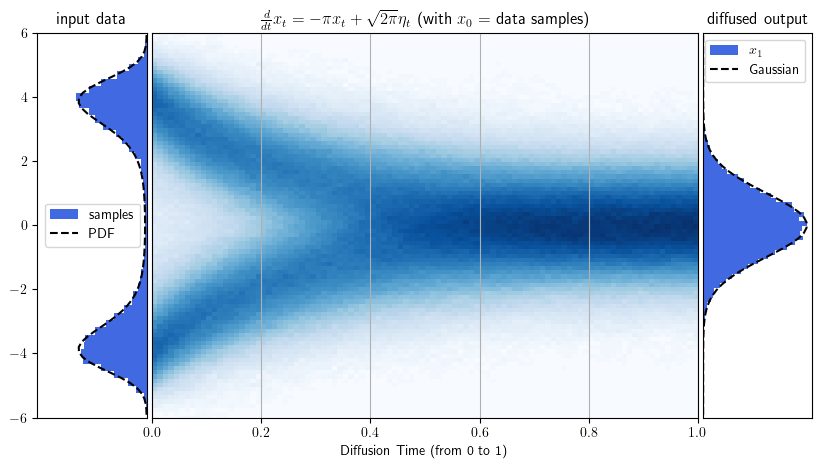

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5), gridspec_kw={'width_ratios': [0.2, 1, 0.2]})

axs[1].hist2d(t_eval.ravel(), diffused_samples.ravel(), norm=mpl.colors.PowerNorm(0.5), cmap='Blues', bins=100);

hist_kwargs = dict(bins=50, color='royalblue', density=True, orientation='horizontal')
axs[0].hist(diffused_samples[0], label="samples", **hist_kwargs)
axs[2].hist(diffused_samples[-1], label=r"$x_1$", **hist_kwargs)
axs[0].invert_xaxis()  # Invert x-axis to place histogram to the left

# Add
x_0 = torch.linspace(-8.0, 8.0, 100)
axs[0].plot(grab(calc_normalized_probability(nf_model, x_0)), grab(x_0), '--k', label="PDF")
axs[2].plot(grab(torch.exp(-x_0**2 / 2)) / (2*np.pi)**0.5, grab(x_0), '--k', label="Gaussian")

# Remove undesired axis ticks and labels
axs[1].set_yticks([])
axs[2].set_yticks([])
axs[0].set_xticks([])
axs[2].set_xticks([])

# Add title
axs[0].set_title("input data")
axs[1].set_title(r"$\frac{d}{dt}  x_t = -\pi x_t + \sqrt{2\pi} \eta_t$  (with $x_0 = $ data samples)")
axs[2].set_title("diffused output")

# Set ylim
axs[0].set_ylim([-6, 6])
axs[1].set_ylim([-6, 6])
axs[2].set_ylim([-6, 6])
axs[0].set_xlim([0.42, 0])
axs[2].set_xlim([0, 0.42])

# Decrease horizontal spacing between subplots
plt.subplots_adjust(wspace=0.02)

# Add legend
axs[0].legend()
axs[1].grid()
axs[2].legend()

axs[1].set_xlabel(r'Diffusion Time (from 0 to 1)');

fig.savefig("diffusion_process.jpg")

### Designing score functions

We now give a simple neural network for the reduced score function and a more
advanced one based on *time embedding*. We will see that the simple one
performs in general even better that the time-embedded one in the case of
1 degree of freedom, but for higher dimensional problems one should use
time embedded neural networks.

In [11]:
class ScoreFunc(torch.nn.Module):
    """A simple score function implemented using dense layers.

    This model takes as input a time parameter `t` and a feature vector `x`,
    and outputs a scalar score. The network consists of fully connected layers
    with SiLU (Swish) activations, except for the final output layer.
    """

    def __init__(self, hidden_sizes: list[int] = [8, 32, 32, 8]):
        super().__init__()
        
        in_features = 2  # for (t, x)
        out_features = 1  # for (score)
        
        layer_sizes = [in_features, *hidden_sizes, out_features]
        layers = []

        for i in range(len(layer_sizes) - 1):
            layers.append(torch.nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:  # No activation on the last layer
                layers.append(torch.nn.SiLU())

        self.net = torch.nn.Sequential(*layers)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        """Forward pass for the model. 

        Args:
            t (torch.Tensor): 1D tensor representing time.
            x (torch.Tensor): Input tensor.
        
        Returns:
            torch.Tensor: Score output.
        """
        if t.ndim == 0:
            t = t.repeat(x.shape[0])

        input_tensor = torch.cat([t[:, None], x], dim=-1)
        return self.net(input_tensor)

In [12]:
# Now the build the model

diffusion_process = DiffusionProcess(ScoreFunc())

In [13]:
from functools import partial

n_epochs = 400

train_kwargs = dict(
    n_epochs = n_epochs,
    hyperparam = dict(lr=0.003, betas=(0.9, 0.99)),
    checkpoint_dict = dict(print_every=50),
    scheduler = partial(
        torch.optim.lr_scheduler.CosineAnnealingLR,                     
        T_max = int(1.01 * n_epochs)                                    
    )
)

In [14]:
diffusion_process.train(data_loader, **train_kwargs)

18:46:39 | Training started for 400 epochs
18:46:40 | Epoch: 50 | loss: 0.3384
18:46:41 | Epoch: 100 | loss: 0.3295
18:46:41 | Epoch: 150 | loss: 0.3335
18:46:42 | Epoch: 200 | loss: 0.3052
18:46:43 | Epoch: 250 | loss: 0.3394
18:46:44 | Epoch: 300 | loss: 0.3463
18:46:44 | Epoch: 350 | loss: 0.3397
18:46:45 | Epoch: 400 | loss: 0.3186
18:46:45 | Training finished (cpu); TIME = 6.07 s


Text(0, 0.5, 'Loss')

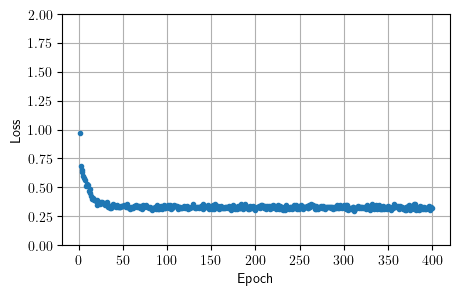

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

loss = diffusion_process.trainer.train_history['loss']
epochs = np.arange(1, len(loss) + 1)
plt.plot(epochs, loss, '.')

# plt.xlim([0, 200])
plt.ylim([0, 2])
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Loss")

In [16]:
x = nf_model.prior.sample(1024 * 64)
with torch.no_grad():
    dm_samples = diffusion_process.reverse(x)

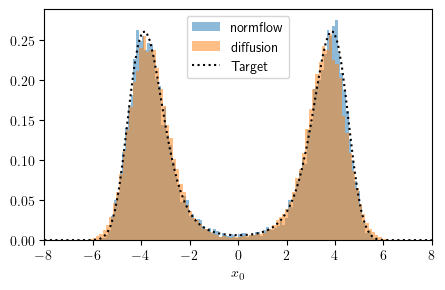

In [17]:
fig, axs = plt.subplots(1, 1, figsize=(5, 3))

kwargs = dict(bins=100, alpha=0.5, density=True)
plt.hist(grab(nf_samples.ravel()), label='normflow', **kwargs)
plt.hist(grab(dm_samples.ravel()), label='diffusion', **kwargs)

x_0 = torch.linspace(-8.0, 8.0, 100)
plt.plot(grab(x_0), grab(calc_normalized_probability(nf_model, x_0)), ':k', label="Target")

plt.xlabel(r'$x_0$')
plt.xlim([-8, 8])
plt.legend()

In [18]:
n_t = 1001
n_x = 1001

t_linspace = torch.linspace(1, 0, n_t)  # for reverse process
x_0 = torch.linspace(-10.0, 10.0, n_x)[:, None]
h = x_0[1] - x_0[0]


def normalize_action(action):
    return action + torch.logsumexp(-action, dim=0) + torch.log(h)


@torch.no_grad
def calc_effective_action(diffusion_process, t, x):
    t =  t[None].repeat(x.shape[0])
    score = diffusion_process.score_fn(t, x)
    avg_score = 0.5 * (score[:-1] + score[1:])
    logq = h * avg_score.cumsum(0)
    return grab(normalize_action(-logq)[:, 0]), grab(score[:, 0])


eff_actions = np.zeros([n_x - 1, n_t]) 

eff_score = np.zeros([n_x, n_t]) 

for ind, t in enumerate(t_linspace):
    eff_actions[:, ind], eff_score[:, ind] = calc_effective_action(diffusion_process, t, x_0)

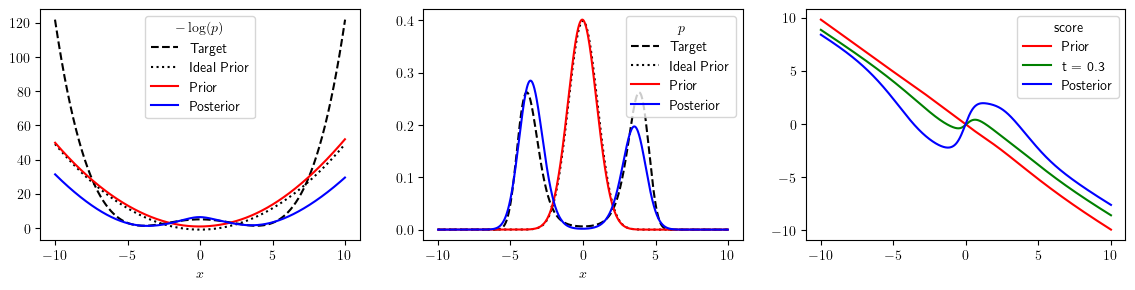

In [19]:
x0_middle = (x_0[:-1] + x_0[1:]) / 2

fig, axs = plt.subplots(1, 3, figsize=(14, 3))

  
action = grab(normalize_action(nf_model.action(x_0)))
axs[0].plot(grab(x_0), action, '--k', label = 'Target')
axs[1].plot(grab(x_0), np.exp(-action), '--k', label = 'Target')

axs[0].plot(grab(x_0), grab(x_0)**2 / 2 - 0.5 * np.log(2 * np.pi), ':k', label = 'Ideal Prior')
axs[1].plot(grab(x_0), np.exp(-grab(x_0)**2 / 2) / (2*np.pi)**0.5, ':k', label = 'Ideal Prior')

axs[0].plot(grab(x0_middle), eff_actions[:, 0], color = 'r', label = 'Prior')
axs[1].plot(grab(x0_middle), np.exp(-eff_actions[:, 0]), color = 'r', label = 'Prior')

axs[0].plot(grab(x0_middle), eff_actions[:, -1], color = 'b', label = 'Posterior')
axs[1].plot(grab(x0_middle), np.exp(- eff_actions[:, -1]), color = 'b', label = 'Posterior')

axs[2].plot(grab(x_0), eff_score[:, 0], color = 'r', label = 'Prior')
axs[2].plot(grab(x_0), eff_score[:, int(0.7 * n_t)], color = 'g', label = 't = 0.3')
axs[2].plot(grab(x_0), eff_score[:, -1], color = 'b', label = 'Posterior')
    
axs[0].set_xlabel(r'$x$')
axs[1].set_xlabel(r'$x$')

axs[0].legend(title=r"$-\log(p)$")
axs[1].legend(title=r"$p$")
axs[2].legend(title=r"score")

In [20]:
t_linspace = grab(t_linspace)

x_0 = grab(x_0)

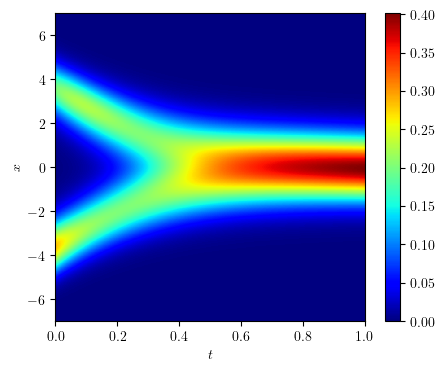

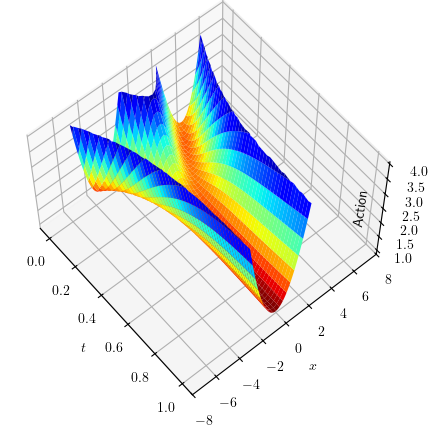

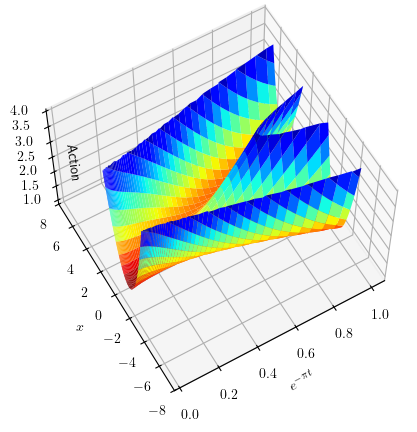

In [21]:
T, X = np.meshgrid(t_linspace, 0.5 * (x_0[:-1] + x_0[1:])[150: 850])

Z = eff_actions[150: 850]

fig = plt.figure(figsize=(5, 4))
pcm = plt.pcolormesh(T, X, np.exp(-Z), cmap='jet', shading='auto')
plt.colorbar(pcm)
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')

fig = plt.figure(figsize=(5, 5))

ax = fig.add_subplot(1, 1, 1, projection='3d')

Z [ Z > 4 ] = np.nan

ax.plot_surface(T, X, Z, cmap='jet_r', antialiased=True)

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$x$')  
ax.set_zlabel('Action', labelpad=-30)
ax.view_init(60, -40)

fig = plt.figure(figsize=(5, 5))

ax = fig.add_subplot(1, 1, 1, projection='3d')

Z [ Z > 4 ] = np.nan

ax.plot_surface(np.exp(-np.pi * T), X, Z, cmap='jet_r', antialiased=True)

ax.set_xlabel(r'$e^{-\pi t}$')
ax.set_ylabel(r'$x$')  
ax.set_zlabel('Action', labelpad=-30)
ax.view_init(60, -120)